# Using yFinance to grab stock price and financial data
Detail Documentary: 
- https://ranaroussi.github.io/yfinance/reference/index.html
- https://github.com/ranaroussi/yfinance

# Content
- #### [Meta information of the company](#Meta-information-of-the-company)
- #### [List the properties available for Apple ticker in yFinance](#List-the-properties-available-for-Apple-ticker-in-yFinance)
- #### [Print the values for each item from ticker.info](#Print-the-values-for-each-item-from-ticker.info)
- #### [Common data and ratio](#Common-data-and-ratio)
- #### [Analyst recommendations](#Analyst-recommendations)
- #### [ESG and Sustainability](#ESG-and-Sustainability)
- #### [Action (Stock Splits)](#Action-(Stock-Splits))
- #### [Dividends](#Dividends)
- #### [SEC Filings](#SEC-Filings)
- #### [Financial Statements](#Financial-Statements)
- #### [Sector and Industry](#Sector-and-Industry)
- #### [Multiple tickers](#Multiple-tickers)

In [41]:
import numpy as np
import pandas as pd
import requests
import yfinance as yf
import matplotlib.pyplot as plt

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [42]:
aapl_df = yf.download('AAPL', start='2019-01-01', end=None, progress=False)
aapl_df.head(2)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.667187,37.889013,36.787045,36.944469,148158800
2019-01-03,33.915253,34.757230,33.869933,34.342203,365248800


In [43]:
aapl_df = aapl_df.droplevel('Ticker', axis=1)
aapl_df.tail(2)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-24,208.369995,208.830002,202.940002,204.889999,47311000
2025-04-25,209.279999,209.750000,206.199997,206.369995,38198600


<Axes: title={'center': "APPLE's stock price"}, xlabel='Date'>

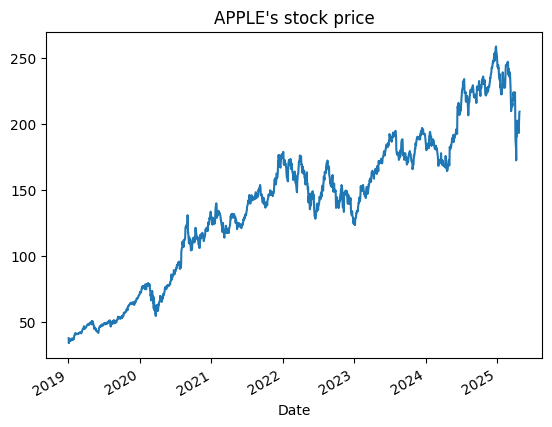

In [44]:
aapl_df['Close'].plot(title="APPLE's stock price")

# Meta information of the company

In [45]:
ticker = yf.Ticker('AAPL')
ticker

yfinance.Ticker object <AAPL>

In [46]:
ticker.history_metadata

{'currency': 'USD',
 'symbol': 'AAPL',
 'exchangeName': 'NMS',
 'fullExchangeName': 'NasdaqGS',
 'instrumentType': 'EQUITY',
 'firstTradeDate': 345479400,
 'regularMarketTime': 1745611202,
 'hasPrePostMarketData': True,
 'gmtoffset': -14400,
 'timezone': 'EDT',
 'exchangeTimezoneName': 'America/New_York',
 'regularMarketPrice': 209.28,
 'fiftyTwoWeekHigh': 260.1,
 'fiftyTwoWeekLow': 169.11,
 'regularMarketDayHigh': 209.43,
 'regularMarketDayLow': 206.2,
 'regularMarketVolume': 38222258,
 'longName': 'Apple Inc.',
 'shortName': 'Apple Inc.',
 'chartPreviousClose': 196.98,
 'previousClose': 208.37,
 'scale': 3,
 'priceHint': 2,
 'currentTradingPeriod': {'pre': {'timezone': 'EDT',
   'end': 1745587800,
   'start': 1745568000,
   'gmtoffset': -14400},
  'regular': {'timezone': 'EDT',
   'end': 1745611200,
   'start': 1745587800,
   'gmtoffset': -14400},
  'post': {'timezone': 'EDT',
   'end': 1745625600,
   'start': 1745611200,
   'gmtoffset': -14400}},
 'tradingPeriods':                  

# List the properties available for Apple ticker in yFinance

In [47]:
dir(ticker)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_analysis',
 '_data',
 '_download_options',
 '_earnings',
 '_earnings_dates',
 '_expirations',
 '_fast_info',
 '_fetch_ticker_tz',
 '_financials',
 '_fundamentals',
 '_funds_data',
 '_get_ticker_tz',
 '_holders',
 '_isin',
 '_lazy_load_price_history',
 '_news',
 '_options2df',
 '_price_history',
 '_quote',
 '_shares',
 '_tz',
 '_underlying',
 'actions',
 'analyst_price_targets',
 'balance_sheet',
 'balancesheet',
 'basic_info',
 'calendar',
 'capital_gains',
 'cash_flow',
 'cashflow',
 'dividends',
 'earnings',
 'earnings_dates',
 'earnings_estimate',
 'earnings_history',
 'eps_revisions',
 'eps_trend',


# Print the values for each item from ticker.info

In [48]:
ticker.info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple TV, Apple Watch, Beats products, and HomePod. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and p

In [49]:
ticker.info['bookValue']

4.438

In [50]:
ticker.info['trailingEps']

6.3

In [51]:
ticker.info['forwardEps']

8.31

In [52]:
ticker.info['earningsGrowth']

0.101

In [53]:
for k, v in ticker.info.items():
    print (k, '\t', v, '\n')

address1 	 One Apple Park Way 

city 	 Cupertino 

state 	 CA 

zip 	 95014 

country 	 United States 

phone 	 (408) 996-1010 

website 	 https://www.apple.com 

industry 	 Consumer Electronics 

industryKey 	 consumer-electronics 

industryDisp 	 Consumer Electronics 

sector 	 Technology 

sectorKey 	 technology 

sectorDisp 	 Technology 

longBusinessSummary 	 Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple TV, Apple Watch, Beats products, and HomePod. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and podcasts, as well as advertising services i

# Common data and ratio

**Beta** is a measure of the stock's volatility relative to the market. Greater than 1, is more volatile than benchmark.

In [54]:
# Latest Beta
ticker.info['beta']

1.259

In [55]:
# Latest annual dividend yield
ticker.info['dividendYield']

0.48

In [56]:
list(map(lambda x: ticker.info[x], 
         ['targetLowPrice', 'targetMeanPrice','targetMedianPrice','targetHighPrice']))

[165.0, 236.2281, 243.0, 300.0]

In [57]:
# Relevant sector
ticker.info['industry']

'Consumer Electronics'

In [58]:
ticker.major_holders

Breakdown,Value
insidersPercentHeld,0.02073
institutionsPercentHeld,0.62955
institutionsFloatPercentHeld,0.64287
institutionsCount,6980.00000


In [59]:
ticker.institutional_holders

,Date Reported,Holder,pctHeld,Shares,Value,pctChange
0,2024-12-31,Vanguard Group Inc,0.0929,1395785512,292109990247,0.0365
1,2024-12-31,Blackrock Inc.,0.0748,1123417607,235108835421,0.0272
2,2024-12-31,State Street Corporation,0.0396,595501507,124626554658,0.0197
3,2024-12-31,"FMR, LLC",0.0227,341640974,71498622621,-0.0611
4,2024-12-31,"Geode Capital Management, LLC",0.0226,340164913,71189712577,0.0189
5,2024-12-31,"Berkshire Hathaway, Inc",0.0200,300000000,62783999633,0.0000
6,2024-12-31,Morgan Stanley,0.0159,238264141,49863919137,0.0294
7,2024-12-31,Price (T.Rowe) Associates Inc,0.0147,220107535,46064104656,-0.0657
8,2024-12-31,NORGES BANK,0.0125,187160162,39168878474,0.0542
9,2024-12-31,JPMORGAN CHASE & CO,0.0122,183008151,38299945617,0.0206


In [60]:
ticker.calendar

{'Dividend Date': datetime.date(2025, 2, 13),
 'Ex-Dividend Date': datetime.date(2025, 2, 10),
 'Earnings Date': [datetime.date(2025, 5, 2)],
 'Earnings High': 1.67,
 'Earnings Low': 1.47,
 'Earnings Average': 1.61151,
 'Revenue High': 95613000000,
 'Revenue Low': 89400000000,
 'Revenue Average': 94059949870}

# Analyst recommendations

We see Buy and Neutral, which is like Hold. There is also Outperform, which means that it should do better than its peers, and Overweight, which means that you should hold more Apple as a percentage in your portfolio than Apple's percentage weight in the relevant index.

This brings up an interesting point. If you are a portfolio manager, how are you evaluated? The obvious answer is "How much money did I make for my clients?" However, that is incorrect. Finance professionals know that they will have good years and bad years. They are happy to be rewarded for the good years, but they don't want to be punished for the bad ones. Years ago, a smart portfolio manager proposed that he be measured relative to an index or benchmark, such as the S&P 500. Thus, if his fund made 15% last year and the S&P made 10%, then the manager outperformed by 5% or 500 basis points. (A basis point is 1/100th of a percentage point.)

If the fund lost10% last year but the S&P lost 15%, the manager still outperformed by 5% or 500 basis points. So the rating "Overweight" is relative to the appropriate benchmark index.

That's how they keep score in asset management world.

In [61]:
ticker.recommendations

,period,strongBuy,buy,hold,sell,strongSell
0,0m,7,23,16,1,1
1,-1m,7,21,14,2,1
2,-2m,7,21,13,2,2
3,-3m,8,21,13,2,2


# ESG and Sustainability

In [62]:
ticker.sustainability

,esgScores
maxAge,86400
totalEsg,18.75
environmentScore,2.05
socialScore,8.35
governanceScore,8.35
ratingYear,2025
ratingMonth,4
highestControversy,3.0
peerCount,235
esgPerformance,LAG_PERF


# Action (Stock Splits)

In [63]:
ticker.actions

,Dividends,Stock Splits
Date,,
1987-05-11 00:00:00-04:00,0.000536,0.0
1987-06-16 00:00:00-04:00,0.000000,2.0
1987-08-10 00:00:00-04:00,0.000536,0.0
1987-11-17 00:00:00-05:00,0.000714,0.0
1988-02-12 00:00:00-05:00,0.000714,0.0
...,...,...
2024-02-09 00:00:00-05:00,0.240000,0.0
2024-05-10 00:00:00-04:00,0.250000,0.0
2024-08-12 00:00:00-04:00,0.250000,0.0


In [64]:
ticker.splits

Date
1987-06-16 00:00:00-04:00    2.0
2000-06-21 00:00:00-04:00    2.0
2005-02-28 00:00:00-05:00    2.0
2014-06-09 00:00:00-04:00    7.0
2020-08-31 00:00:00-04:00    4.0
Name: Stock Splits, dtype: float64

# Dividends

In [65]:
ticker.dividends

Date
1987-05-11 00:00:00-04:00    0.000536
1987-08-10 00:00:00-04:00    0.000536
1987-11-17 00:00:00-05:00    0.000714
1988-02-12 00:00:00-05:00    0.000714
1988-05-16 00:00:00-04:00    0.000714
                               ...   
2024-02-09 00:00:00-05:00    0.240000
2024-05-10 00:00:00-04:00    0.250000
2024-08-12 00:00:00-04:00    0.250000
2024-11-08 00:00:00-05:00    0.250000
2025-02-10 00:00:00-05:00    0.250000
Name: Dividends, Length: 86, dtype: float64

In [66]:
# Latest annual yield
ticker.info['dividendYield']

0.48

# SEC Filings

In [67]:
ticker.sec_filings

[{'date': datetime.date(2025, 4, 4),
  'epochDate': 1743724800,
  'type': 'SD',
  'title': 'Specialized Disclosure Report filed pursuant to Section 1502 of the Dodd-Frank Wall Street Reform and Consumer Protection Act relating to the use of conflict minerals (Rule 13p-1)',
  'edgarUrl': 'https://finance.yahoo.com/sec-filing/AAPL/0001140361-25-012359_320193',
  'exhibits': {'EX-1.01': 'https://cdn.yahoofinance.com/prod/sec-filings/0000320193/000114036125012359/ef20046400_ex1-01.htm',
   'SD': 'https://cdn.yahoofinance.com/prod/sec-filings/0000320193/000114036125012359/ef20046400_sd.htm'},
  'maxAge': 1},
 {'date': datetime.date(2025, 2, 25),
  'epochDate': 1740441600,
  'type': '8-K',
  'title': 'Corporate Changes & Voting Matters',
  'edgarUrl': 'https://finance.yahoo.com/sec-filing/AAPL/0001140361-25-005876_320193',
  'exhibits': {'EXCEL': 'https://s3.amazonaws.com/finance-pri-uw2/sec-filings/0000320193/000114036125005876/Financial_Report.xlsx',
   '8-K': 'https://cdn.yahoofinance.com

# Financial Statements
- ticker.financials
- ticker.balancesheet
- ticker.cashflow 
## - income statement
- ticker.income_stmt
- ticker.quarterly_income_stmt
- ticker.get_income_stmt() 
## - balance sheet
- ticker.balance_sheet
- ticker.quarterly_balance_sheet
- balance sheet columns: ticker.balance_sheet.axes[0]
## - cash flow statement
- ticker.cashflow
- ticker.quarterly_cashflow


In [68]:
ticker.balance_sheet

,2024-09-30,2023-09-30,2022-09-30,2021-09-30,2020-09-30
Treasury Shares Number,NaN,0.0,NaN,NaN,NaN
Ordinary Shares Number,15116786000.0,15550061000.0,15943425000.0,16426786000.0,NaN
Share Issued,15116786000.0,15550061000.0,15943425000.0,16426786000.0,NaN
Net Debt,76686000000.0,81123000000.0,96423000000.0,89779000000.0,NaN
Total Debt,106629000000.0,111088000000.0,132480000000.0,136522000000.0,NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,65171000000.0,61555000000.0,48304000000.0,62639000000.0,NaN
Other Short Term Investments,35228000000.0,31590000000.0,24658000000.0,27699000000.0,NaN
Cash And Cash Equivalents,29943000000.0,29965000000.0,23646000000.0,34940000000.0,NaN
Cash Equivalents,2744000000.0,1606000000.0,5100000000.0,17635000000.0,NaN


In [69]:
ticker.balance_sheet.axes[0]

Index(['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued',
       'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital',
       'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations',
       'Common Stock Equity', 'Total Capitalization',
       'Total Equity Gross Minority Interest', 'Stockholders Equity',
       'Gains Losses Not Affecting Retained Earnings',
       'Other Equity Adjustments', 'Retained Earnings', 'Capital Stock',
       'Common Stock', 'Total Liabilities Net Minority Interest',
       'Total Non Current Liabilities Net Minority Interest',
       'Other Non Current Liabilities', 'Tradeand Other Payables Non Current',
       'Long Term Debt And Capital Lease Obligation',
       'Long Term Capital Lease Obligation', 'Long Term Debt',
       'Current Liabilities', 'Other Current Liabilities',
       'Current Deferred Liabilities', 'Current Deferred Revenue',
       'Current Debt And Capital Lease Obligation',
       'Current C

In [70]:
ticker.financials

,2024-09-30,2023-09-30,2022-09-30,2021-09-30,2020-09-30
Tax Effect Of Unusual Items,0.0,0.0,0.0,0.0,NaN
Tax Rate For Calcs,0.241,0.147,0.162,0.133,NaN
Normalized EBITDA,134661000000.0,125820000000.0,130541000000.0,123136000000.0,NaN
Net Income From Continuing Operation Net Minority Interest,93736000000.0,96995000000.0,99803000000.0,94680000000.0,NaN
Reconciled Depreciation,11445000000.0,11519000000.0,11104000000.0,11284000000.0,NaN
Reconciled Cost Of Revenue,210352000000.0,214137000000.0,223546000000.0,212981000000.0,NaN
EBITDA,134661000000.0,125820000000.0,130541000000.0,123136000000.0,NaN
EBIT,123216000000.0,114301000000.0,119437000000.0,111852000000.0,NaN
Net Interest Income,NaN,-183000000.0,-106000000.0,198000000.0,890000000.0
Interest Expense,NaN,3933000000.0,2931000000.0,2645000000.0,2873000000.0


In [71]:
ticker.balancesheet

,2024-09-30,2023-09-30,2022-09-30,2021-09-30,2020-09-30
Treasury Shares Number,NaN,0.0,NaN,NaN,NaN
Ordinary Shares Number,15116786000.0,15550061000.0,15943425000.0,16426786000.0,NaN
Share Issued,15116786000.0,15550061000.0,15943425000.0,16426786000.0,NaN
Net Debt,76686000000.0,81123000000.0,96423000000.0,89779000000.0,NaN
Total Debt,106629000000.0,111088000000.0,132480000000.0,136522000000.0,NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,65171000000.0,61555000000.0,48304000000.0,62639000000.0,NaN
Other Short Term Investments,35228000000.0,31590000000.0,24658000000.0,27699000000.0,NaN
Cash And Cash Equivalents,29943000000.0,29965000000.0,23646000000.0,34940000000.0,NaN
Cash Equivalents,2744000000.0,1606000000.0,5100000000.0,17635000000.0,NaN


In [72]:
ticker.cashflow

,2024-09-30,2023-09-30,2022-09-30,2021-09-30,2020-09-30
Free Cash Flow,108807000000.0,99584000000.0,111443000000.0,92953000000.0,NaN
Repurchase Of Capital Stock,-94949000000.0,-77550000000.0,-89402000000.0,-85971000000.0,NaN
Repayment Of Debt,-9958000000.0,-11151000000.0,-9543000000.0,-8750000000.0,NaN
Issuance Of Debt,0.0,5228000000.0,5465000000.0,20393000000.0,NaN
Issuance Of Capital Stock,NaN,NaN,NaN,1105000000.0,880000000.0
Capital Expenditure,-9447000000.0,-10959000000.0,-10708000000.0,-11085000000.0,NaN
Interest Paid Supplemental Data,NaN,3803000000.0,2865000000.0,2687000000.0,3002000000.0
Income Tax Paid Supplemental Data,26102000000.0,18679000000.0,19573000000.0,25385000000.0,NaN
End Cash Position,29943000000.0,30737000000.0,24977000000.0,35929000000.0,NaN
Beginning Cash Position,30737000000.0,24977000000.0,35929000000.0,39789000000.0,NaN


# Sector and Industry
The Sector and Industry modules allow you to access the US market information.
- Common information
<pre>tech.key
tech.name
tech.symbol
tech.ticker
tech.overview
tech.top_companies
tech.research_reports</pre>
<BR>
- Sector information
<pre>tech.top_etfs
tech.top_mutual_funds
tech.industries</pre>
<BR>
- Industry information
<pre>software.sector_key
software.sector_name
software.top_performing_companies
software.top_growth_companies</pre>

In [73]:
yf.Sector

yfinance.domain.sector.Sector

In [74]:
tech = yf.Sector('technology')
software = yf.Industry('software-infrastructure')

In [75]:
tech.top_companies

,name,rating,market weight
symbol,,,
AAPL,Apple Inc.,Buy,0.187429
MSFT,Microsoft Corporation,Strong Buy,0.172613
NVDA,NVIDIA Corporation,Strong Buy,0.161076
AVGO,Broadcom Inc.,Strong Buy,0.053217
ORCL,Oracle Corporation,Buy,0.022738
PLTR,Palantir Technologies Inc.,Hold,0.015222
CRM,"Salesforce, Inc.",Buy,0.015187
CSCO,"Cisco Systems, Inc.",Buy,0.013382
IBM,International Business Machines Corporation,Buy,0.012732


In [76]:
tech.top_etfs

{'VGT': 'Vanguard Information Tech ETF',
 'XLK': 'SPDR Select Sector Fund - Techn',
 'SMH': 'VanEck Semiconductor ETF',
 'IYW': 'iShares U.S. Technology ETF',
 'FTEC': 'Fidelity MSCI Information Techn',
 'SOXX': 'iShares Semiconductor ETF',
 'IGV': 'iShares Expanded Tech-Software ',
 'CIBR': 'First Trust NASDAQ Cybersecurit',
 'FNGU': 'MicroSectors FANG  Index 3X Lev',
 'IGM': 'iShares Expanded Tech Sector ET'}

In [77]:
software.top_performing_companies

,name,ytd return,last price,target price
symbol,,,,
JNVR,DeFi Development Corp.,9.6921,51.91,NaN
MLGO,MicroAlgo Inc.,1.1064,7.92,NaN
ATGL,Alpha Technology Group Limited,0.8755,26.52,NaN
STNE,StoneCo Ltd.,0.7252,13.75,80.9779
PAGS,PagSeguro Digital Ltd.,0.5783,9.88,62.0270


# Multiple tickers
To initialize multiple Ticker objects

In [78]:
group_tickers = yf.Tickers('msft aapl goog')

# access each ticker using (example)
group_tickers.tickers['MSFT'].info

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices and solutions worldwide. The Productivity and Business Processes segment offers office, exchange, SharePoint, Microsoft Teams, office 365 Security and Compliance, Microsoft viva, and Microsoft 365 copilot; and office consumer services, such as Microsoft 365 consumer subscriptions, Office licensed on-premises, and other office services. This segment also provides LinkedIn; and dynamics business solutions, including Dynamics 365, a set of intelligent, cloud-based applications across ERP, CRM, power 

period : {'1d', '5d', '1mo', '3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max'}

In [79]:
#group_tickers.tickers['AAPL'].history(period="1y")
#group_tickers.tickers['AAPL'].history(period="1mo")
group_tickers.tickers['AAPL'].history(period="5d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-21 00:00:00-04:00,193.270004,193.800003,189.809998,193.160004,46742500,0.0,0.0
2025-04-22 00:00:00-04:00,196.119995,201.589996,195.970001,199.740005,52976400,0.0,0.0
2025-04-23 00:00:00-04:00,206.000000,208.000000,202.800003,204.600006,52929200,0.0,0.0
2025-04-24 00:00:00-04:00,204.889999,208.830002,202.940002,208.369995,47311000,0.0,0.0
2025-04-25 00:00:00-04:00,206.369995,209.750000,206.199997,209.279999,38198600,0.0,0.0


In [80]:
group_tickers.tickers['GOOG'].actions

,Dividends,Stock Splits
Date,,
2014-03-27 00:00:00-04:00,0.0,2.002000
2015-04-27 00:00:00-04:00,0.0,1.002746
2022-07-18 00:00:00-04:00,0.0,20.000000
2024-06-10 00:00:00-04:00,0.2,0.000000
2024-09-09 00:00:00-04:00,0.2,0.000000
2024-12-09 00:00:00-05:00,0.2,0.000000
2025-03-10 00:00:00-04:00,0.2,0.000000
